# Voteview — discovery to plot

The narrative arc, entirely over MCP: find what exists, fetch it, plot it. No
local files, no knowledge of how the series were built.

That last part is the test. Voteview needed no server work — it reuses the
stored-series tools WONDER and NVSR use — so if this notebook reads naturally,
the abstraction holds.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append("../")
sys.path.append("../../")

from matplotlib import pyplot
from lib import config
from utils import (search_catalog, get_series, plot_series, plot_group,
                   stamp_source, to_arrays)

pyplot.style.use(config.glyfish_style)

## 1. Discovery

Start from the catalog, not from knowing an id. Two facets: `measure` and
`chamber`.

In [2]:
entries = sorted(await search_catalog(), key=lambda e: e["series_id"])
print(f"{len(entries)} Voteview series\n")
for e in entries:
    facets = e.get("facets") or {}
    print(f"  {facets.get('measure',''):26s} {facets.get('chamber',''):7s} "
          f"{e['observation_start']}..{e['observation_end']}")


8 Voteview series

  effective_parties          house   1789-01-01..2025-01-01
  effective_parties          senate  1789-01-01..2025-01-01
  median_gap                 house   1857-01-01..2025-01-01
  median_gap                 senate  1857-01-01..2025-01-01
  moderate_bloc              house   1857-01-01..2025-01-01
  moderate_bloc              senate  1857-01-01..2025-01-01
  party_predicts_position    house   1789-01-01..2025-01-01
  party_predicts_position    senate  1789-01-01..2025-01-01


Four measures, two chambers. Note the two different spans — that is not an
accident of coverage, it is what each measure can express. Two of them never
name a party, so they reach 1789; the other two compare Democrats to
Republicans, who do not both exist before 1857.

## 2. Fetch

The catalog's `retrieval` block says which tool serves a series, so a consumer
never has to know that Voteview is stored rather than live.

In [3]:
target = next(e for e in entries
              if (e.get("facets") or {}).get("measure") == "median_gap"
              and (e.get("facets") or {}).get("chamber") == "house")
print("  retrieval:", target["retrieval"])

series = await get_series(target["retrieval"]["native_id"])
years, values = to_arrays(series)
print(f"\n  {series['title']}")
print(f"  {len(years)} observations, {years[0]}-{years[-1]}, every {years[1]-years[0]} years")
print(f"  lowest  {values.min():.3f} in {years[values.argmin()]}")
print(f"  highest {values.max():.3f} in {years[values.argmax()]}")

  retrieval: {'tool': 'timeseries_source_data', 'source': 'voteview', 'native_id': 'voteview/median_gap/house'}

  Distance between the party medians — US House
  85 observations, 1857-2025, every 2 years
  lowest  0.497 in 1947
  highest 0.925 in 2025


## 3. Plot

The distance between the two parties' medians, 1857 to today.

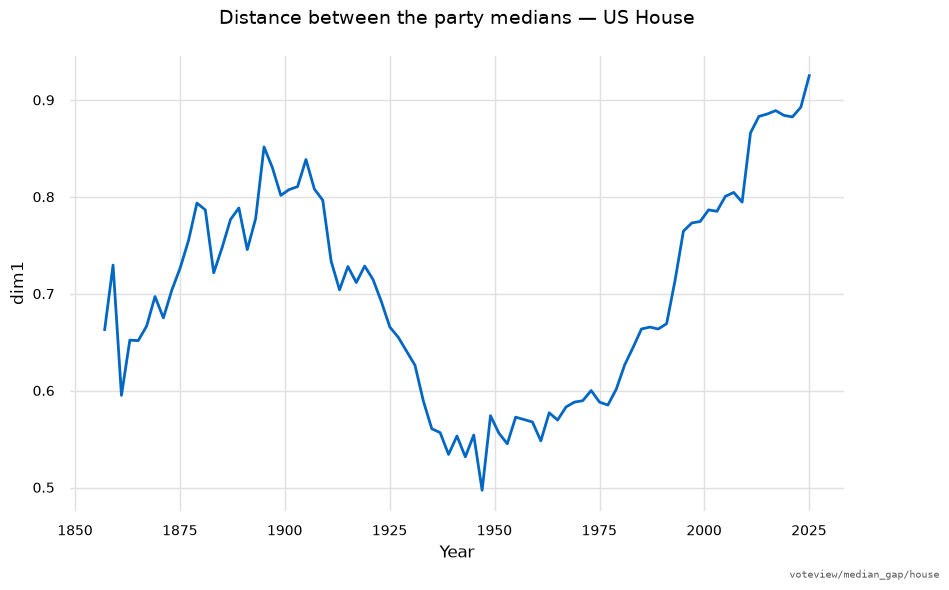

In [4]:
plot_series(series)

A peak around 1900, the postwar trough, and a climb since the 1970s past the
Gilded Age. The 1947 low of 0.498 is the closest the two parties have ever
been.

## 4. The comparison that changes the reading

The gap alone suggests a smooth return to an earlier state. Overlaying the
count of members who sit *between* the parties says otherwise.

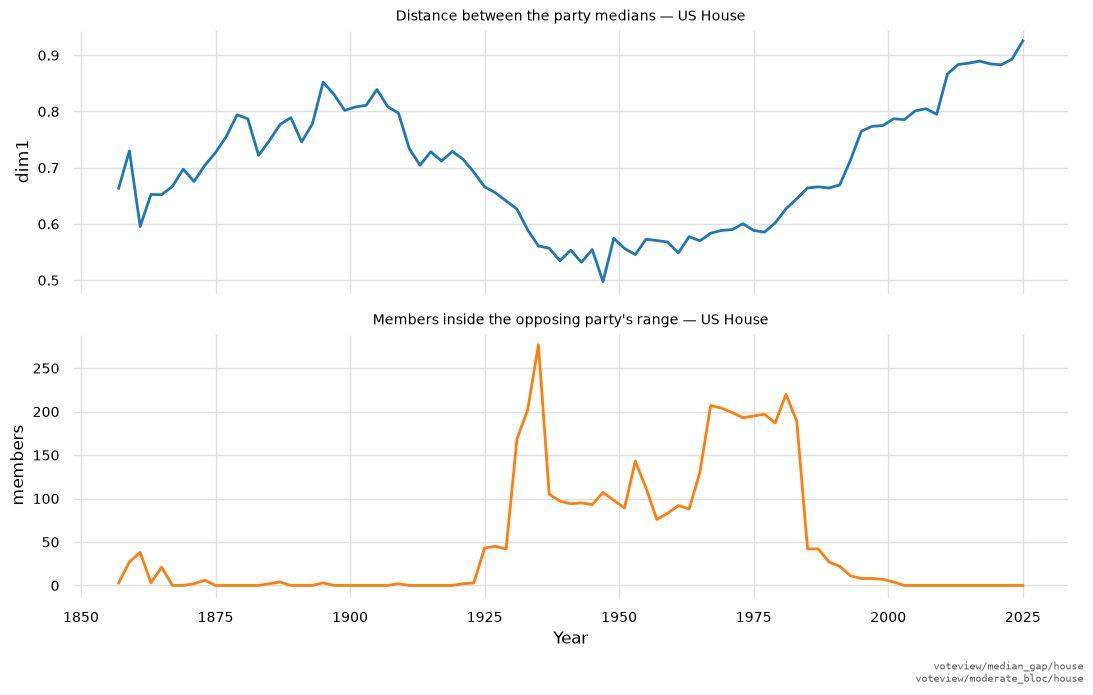

In [5]:
bloc = await get_series("voteview/moderate_bloc/house")

figure, (top, bottom) = pyplot.subplots(2, 1, figsize=(11, 7), sharex=True)
for axis, record, colour in ((top, series, "tab:blue"), (bottom, bloc, "tab:orange")):
    years, values = to_arrays(record)          # (years, values) -- x then y
    axis.plot(years, values, lw=2, color=colour)
    axis.set_ylabel(record["units"])
    axis.set_title(record["title"], fontsize=10)
bottom.set_xlabel("Year")
figure.tight_layout()
stamp_source(series, bloc, figure=figure)

The bloc reaches zero in 2007 and stays there while the gap keeps rising. The
parties went on separating after there was already nobody in between — which
is why both are stored rather than one standing in for the other.

## 5. Both chambers

The Senate tracks the House closely, which is worth knowing before treating
them as independent evidence.

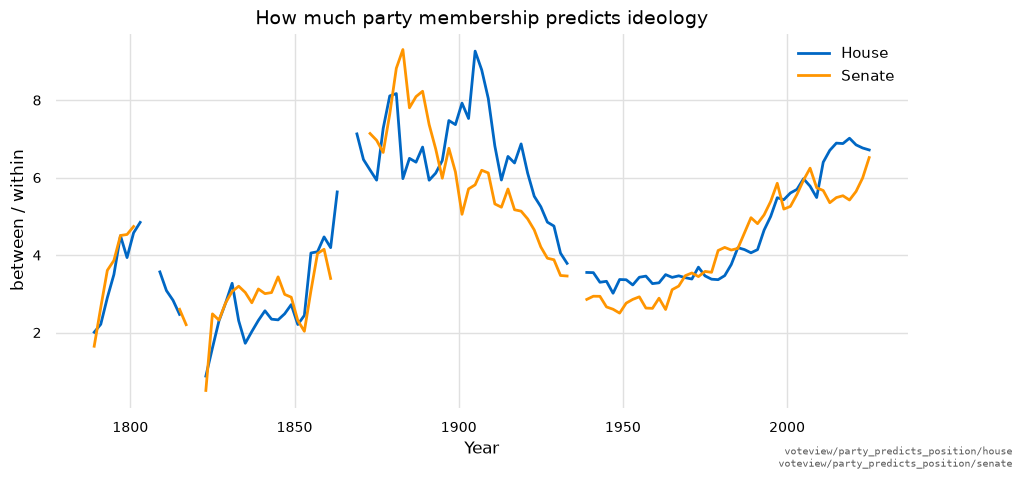

In [6]:
house = await get_series("voteview/party_predicts_position/house")
senate = await get_series("voteview/party_predicts_position/senate")
plot_group([house, senate], ["House", "Senate"],
           title="How much party membership predicts ideology",
           ylabel="between / within")


## 6. Centring it — a derived measure, computed here

Everything above plots a stored series as served. This one is computed from it.

The gap has no natural zero: 0.7 means nothing until you know what this chamber
usually does. Subtracting each chamber's own long-run mean fixes that, and the
sign then carries the claim — **above the line is more polarized than the
historical average, below it is more aligned**.

Nothing new is fetched. It is `values - values.mean()` over the series already
in hand, which is why it is not a ninth stored series: a pure transform of one
row with no additional input.

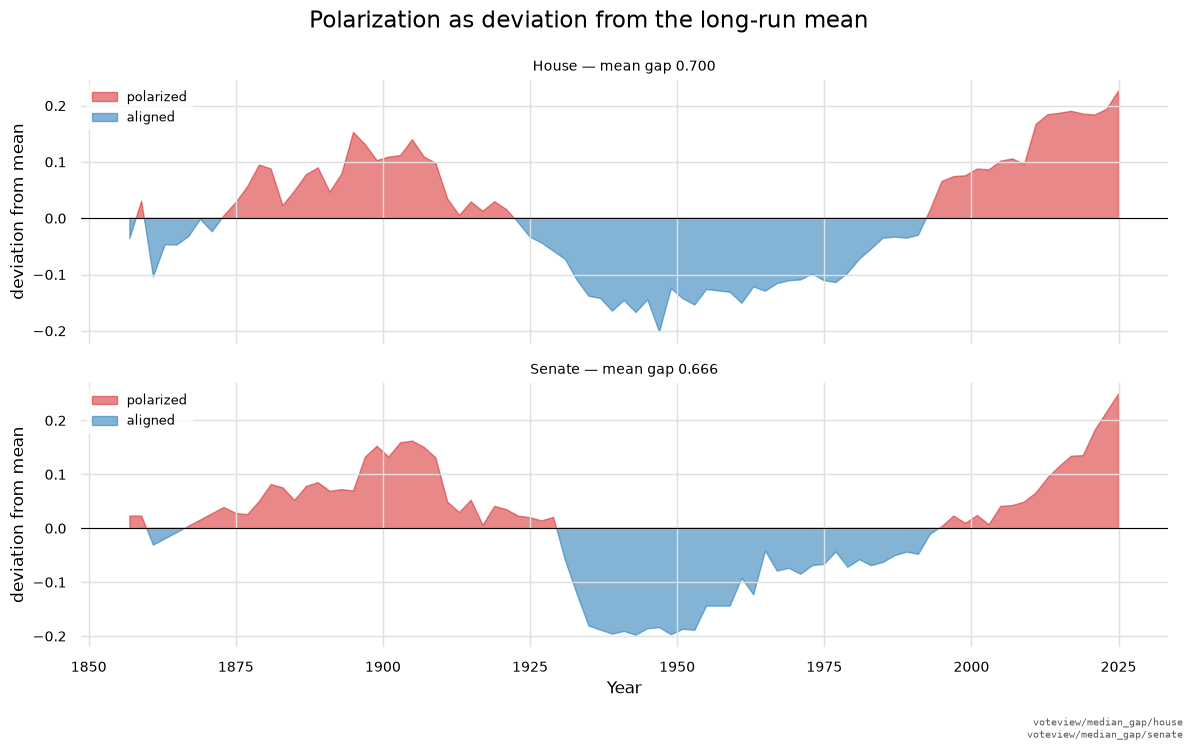

In [7]:
import numpy

gaps = {"House": await get_series("voteview/median_gap/house"),
        "Senate": await get_series("voteview/median_gap/senate")}

figure, axes = pyplot.subplots(2, 1, figsize=(12, 7.5), sharex=True)
for axis, (chamber, record) in zip(axes, gaps.items()):
    years, values = to_arrays(record)
    deviation = values - values.mean()

    axis.fill_between(years, deviation, 0, where=deviation >= 0, color="tab:red",
                      alpha=0.55, interpolate=True, label="polarized")
    axis.fill_between(years, deviation, 0, where=deviation <= 0, color="tab:blue",
                      alpha=0.55, interpolate=True, label="aligned")
    axis.axhline(0, color="black", lw=0.8)
    axis.set_ylabel("deviation from mean")
    axis.set_title(f"{chamber} — mean gap {values.mean():.3f}", fontsize=10)
    axis.legend(loc="upper left", fontsize=9)

axes[-1].set_xlabel("Year")
figure.suptitle("Polarization as deviation from the long-run mean")
figure.tight_layout()
stamp_source(*gaps.values(), figure=figure)

`interpolate=True` is what makes the bands meet cleanly at the crossings;
without it `fill_between` clips at the sample points and leaves notches where
the sign changes.

Three regimes, and the sign makes them legible without reading values off an
axis: polarized through the Gilded Age into the 1910s, aligned from the late
1920s to about 1990 — the Senate's trough is deeper and flatter than the
House's — and polarized again since, ending higher than the 1900s peak in both
chambers.

The two means differ (House 0.700, Senate 0.666), so each chamber is judged
against its own record rather than a shared baseline. That is deliberate: the
question is whether *this* chamber is unusual for itself.

The breaks in each line are Congresses where the second party held under 25%
of the chamber. The measure declines rather than compare a large median against
a rump, and the line breaks rather than draw a segment through a value that was
never computed.

They are not all early. The House loses 9 — 1805, 1807, 1817–1821, then 1865,
1867 and 1935, 1937. The Senate loses 15, including a run from 1803 to 1813 and
another from 1863 to 1871, because a chamber of 30-odd seats swings past the
threshold more easily than one of 200. Reconstruction and the New Deal are one-
party enough to gate on both sides.

For the same numbers computed from the raw panel, with the reduction visible,
see [`client.ipynb`](client.ipynb).